In [1]:
import os

# Setup Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown, Latex

# Baseline Imports
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

import torch

from tabpfn import TabPFNClassifier, TabPFNRegressor
from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNClassifier, AutoTabPFNRegressor


In [2]:
#使用MACCS Key
maccs_df = pd.read_excel('smiles_logkoh_maccs.xlsx', sheet_name='Sheet1', header=0)
X = maccs_df.filter(regex='MACCS_\d+')  
y = maccs_df['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
print("特征数据类型:\n", X_train.dtypes)

In [4]:
X_train.head()

,MACCS_1,MACCS_2,MACCS_3,MACCS_4,MACCS_5,MACCS_6,MACCS_7,MACCS_8,MACCS_9,MACCS_10,...,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166,MACCS_167
254,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,1,0,1,1,1,0
881,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
312,0,0,0,0,0,0,0,0,0,0,...,1,1,1,0,1,1,1,1,1,0
451,0,0,0,0,0,0,0,0,0,0,...,1,0,1,1,0,1,1,1,1,0
221,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,1,1,1,1,1,0


In [5]:
#训练模型
reg = TabPFNRegressor(random_state=42)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

TabPFN RMSE: 0.3830


Text(0.5, 1.0, 'Model Comparison - 5-fold Cross-validation \n (Root Mean Squared Error - Smaller is better)')

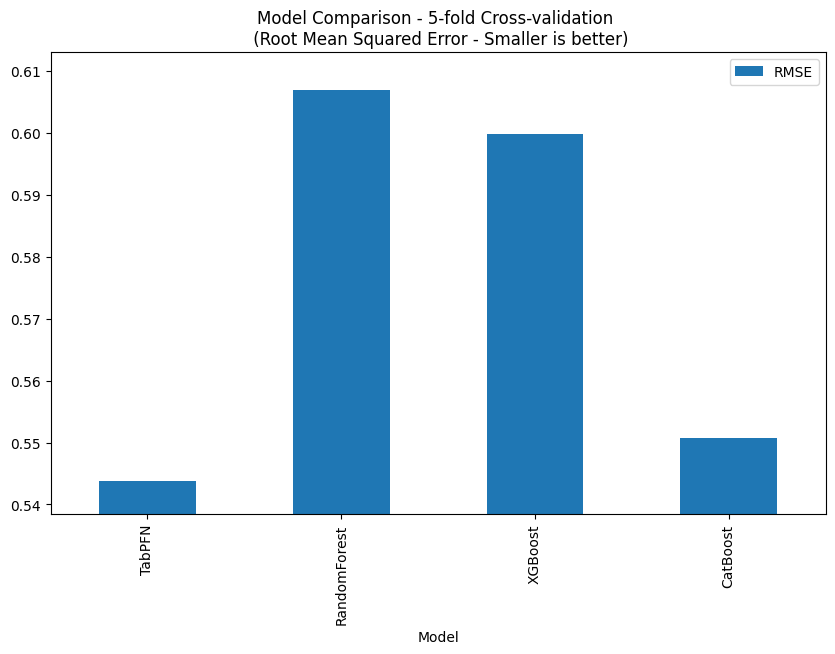

In [15]:
#与基线比较
models = [
    ('TabPFN', TabPFNRegressor(random_state=42)),
    ('RandomForest', RandomForestRegressor(random_state=42)),
    ('XGBoost', XGBRegressor(random_state=42)),
    ('CatBoost', CatBoostRegressor(random_state=42, verbose=0))
]

scoring = 'neg_root_mean_squared_error'
scores = {name: cross_val_score(model, X, y, cv=5, scoring=scoring, n_jobs=-1).mean()
          for name, model in models}


# 绘制相关图
df = pd.DataFrame(list(scores.items()), columns=['Model', 'RMSE'])
df.RMSE = -df.RMSE # Smaller is better
ax = df.plot(x='Model', y='RMSE', kind='bar', figsize=(10, 6))
ax.set_ylim(df['RMSE'].min() * 0.99, df['RMSE'].max() * 1.01)
ax.set_title('Model Comparison - 5-fold Cross-validation \n (Root Mean Squared Error - Smaller is better)')

In [3]:
#使用Morgan指纹(1024位)
Morgan_DF = pd.read_excel('smiles_logkoh_with_morgan.xlsx', sheet_name='Sheet1', header=0)
X = Morgan_DF.filter(regex='bit_\d+')  
y = Morgan_DF['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
X_train.head()

,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,...,bit_1014,bit_1015,bit_1016,bit_1017,bit_1018,bit_1019,bit_1020,bit_1021,bit_1022,bit_1023
254,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
881,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
312,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
451,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
221,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [6]:
Morgan_reg = TabPFNRegressor(random_state=42,ignore_pretraining_limits=True)
Morgan_reg.fit(X_train, y_train)
y_pred = Morgan_reg.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\tabpfn\regressor.py:426: UserWarning: Number of features 1024 is greater than the maximum Number of features 500 supported by the model. You may see degraded performance.
  X, y, feature_names_in, n_features_in = validate_Xy_fit(


TabPFN RMSE: 0.4452


In [7]:
#使用Morgan指纹(512位)
Morgan_DF_512 = pd.read_excel('smiles_logkoh_with_morgan_512.xlsx', sheet_name='Sheet1', header=0)
X = Morgan_DF_512.filter(regex='bit_\d+')  
y = Morgan_DF_512['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
X_train.head()

,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,...,bit_502,bit_503,bit_504,bit_505,bit_506,bit_507,bit_508,bit_509,bit_510,bit_511
254,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
881,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
312,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
451,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
221,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [8]:
Morgan_reg_512 = TabPFNRegressor(random_state=42,ignore_pretraining_limits=True)
Morgan_reg_512.fit(X_train, y_train)
y_pred = Morgan_reg_512.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\tabpfn\regressor.py:426: UserWarning: Number of features 512 is greater than the maximum Number of features 500 supported by the model. You may see degraded performance.
  X, y, feature_names_in, n_features_in = validate_Xy_fit(


TabPFN RMSE: 0.4286


In [9]:
#使用Morgan指纹(256位)
Morgan_DF_256 = pd.read_excel('smiles_logkoh_with_morgan_256.xlsx', sheet_name='Sheet1', header=0)
X = Morgan_DF_256.filter(regex='bit_\d+')  
y = Morgan_DF_256['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
X_train.head()

,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,...,bit_246,bit_247,bit_248,bit_249,bit_250,bit_251,bit_252,bit_253,bit_254,bit_255
254,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
881,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
312,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
451,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
221,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [11]:
Morgan_reg_256 = TabPFNRegressor(random_state=42)
Morgan_reg_256.fit(X_train, y_train)
y_pred = Morgan_reg_256.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

TabPFN RMSE: 0.4384


In [15]:
#使用Morgan指纹(2048位)
Morgan_DF_2048 = pd.read_excel('smiles_logkoh_with_morgan_2048.xlsx', sheet_name='Sheet1', header=0)
X = Morgan_DF_2048.filter(regex='bit_\d+')  
y = Morgan_DF_2048['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
X_train.head()

,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,...,bit_2038,bit_2039,bit_2040,bit_2041,bit_2042,bit_2043,bit_2044,bit_2045,bit_2046,bit_2047
254,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
881,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
312,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
451,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
221,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
X_test.head()

,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,...,bit_2038,bit_2039,bit_2040,bit_2041,bit_2042,bit_2043,bit_2044,bit_2045,bit_2046,bit_2047
1048,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
265,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
109,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
299,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
753,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
Morgan_reg_2048 = TabPFNRegressor(random_state=42,ignore_pretraining_limits=True)
Morgan_reg_2048.fit(X_train, y_train)
y_pred = Morgan_reg_2048.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\tabpfn\regressor.py:426: UserWarning: Number of features 2048 is greater than the maximum Number of features 500 supported by the model. You may see degraded performance.
  X, y, feature_names_in, n_features_in = validate_Xy_fit(


TabPFN RMSE: 0.4638


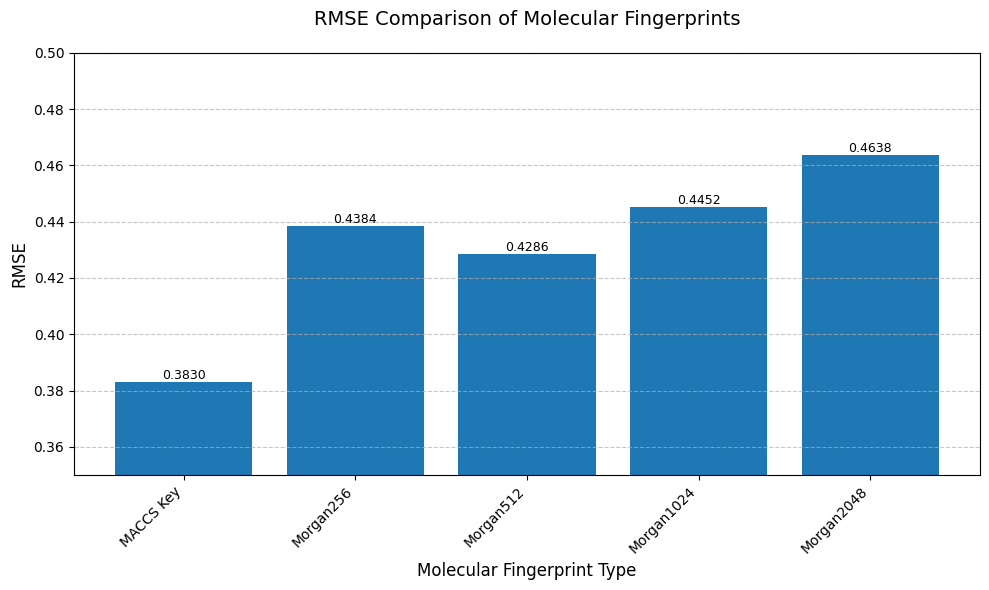

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
fingerprints = ['MACCS Key', 'Morgan256', 'Morgan512', 'Morgan1024', 'Morgan2048']
rmse_values = [0.3830, 0.4384, 0.4286, 0.4452, 0.4638]

# 创建柱状图
plt.figure(figsize=(10, 6))
bars = plt.bar(fingerprints, rmse_values, color='#1f77b4')

# 添加标题和标签
plt.title('RMSE Comparison of Molecular Fingerprints', fontsize=14, pad=20)
plt.xlabel('Molecular Fingerprint Type', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylim(0.35, 0.50)  # 优化y轴范围

# 在柱子上方显示数值
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom',
             fontsize=9)

# 添加网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 调整布局防止文字被截断
plt.tight_layout()

# 显示图表
plt.show()

In [20]:
#使用Morgan指纹
cMorgan_DF = pd.read_excel('processed_fingerprints.xlsx', sheet_name='Sheet1', header=0)
X = cMorgan_DF.filter(regex='FP_\d+')  
y = cMorgan_DF['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
X_train.head()

,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,FP_1014,FP_1015,FP_1016,FP_1017,FP_1018,FP_1019,FP_1020,FP_1021,FP_1022,FP_1023
254,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
881,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
312,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
451,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
221,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [21]:
cMorgan_reg = TabPFNRegressor(random_state=42,ignore_pretraining_limits=True)
cMorgan_reg.fit(X_train, y_train)
y_pred = cMorgan_reg.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\tabpfn\regressor.py:426: UserWarning: Number of features 1024 is greater than the maximum Number of features 500 supported by the model. You may see degraded performance.
  X, y, feature_names_in, n_features_in = validate_Xy_fit(


TabPFN RMSE: 0.4143


In [22]:
from sklearn.preprocessing import StandardScaler

# 初始化标准化器
scaler = StandardScaler()

# 对训练集进行拟合和转换，并保持DataFrame结构
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

# 对测试集进行转换（使用训练集的拟合结果），并保持DataFrame结构
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 查看归一化后的训练集前5行
X_train.head()

,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,FP_1014,FP_1015,FP_1016,FP_1017,FP_1018,FP_1019,FP_1020,FP_1021,FP_1022,FP_1023
0,-0.118323,-0.440183,-0.087379,-0.091192,-0.197469,-0.108324,-0.035921,-0.062298,-0.076373,-0.1159,...,-0.091192,-0.08053,-0.035921,-0.241326,-0.088273,-0.253199,-0.084057,-0.058722,-0.131726,-0.050833
1,-0.118323,-0.440183,-0.087379,-0.091192,-0.197469,-0.108324,-0.035921,-0.062298,-0.076373,-0.1159,...,-0.091192,-0.08053,-0.035921,-0.241326,-0.088273,-0.253199,-0.084057,-0.058722,-0.131726,-0.050833
2,-0.118323,1.148571,-0.087379,-0.091192,-0.197469,-0.108324,-0.035921,-0.062298,-0.076373,-0.1159,...,-0.091192,-0.08053,-0.035921,2.596087,-0.088273,-0.253199,-0.084057,-0.058722,-0.131726,-0.050833
3,-0.118323,-0.440183,-0.087379,-0.091192,-0.197469,-0.108324,-0.035921,-0.062298,-0.076373,-0.1159,...,-0.091192,-0.08053,-0.035921,-0.241326,-0.088273,-0.253199,-0.084057,-0.058722,-0.131726,-0.050833
4,-0.118323,-0.440183,-0.087379,-0.091192,-0.197469,-0.108324,-0.035921,-0.062298,-0.076373,-0.1159,...,-0.091192,-0.08053,-0.035921,2.596087,-0.088273,-0.253199,-0.084057,-0.058722,-0.131726,-0.050833


In [23]:
csMorgan_reg = TabPFNRegressor(random_state=42,ignore_pretraining_limits=True)
csMorgan_reg.fit(X_train, y_train)
y_pred = csMorgan_reg.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\tabpfn\regressor.py:426: UserWarning: Number of features 1024 is greater than the maximum Number of features 500 supported by the model. You may see degraded performance.
  X, y, feature_names_in, n_features_in = validate_Xy_fit(


TabPFN RMSE: 0.4119


In [24]:
#使用Morgan_512指纹
cMorgan_DF_512 = pd.read_excel('processed_fingerprints_512.xlsx', sheet_name='Sheet1', header=0)
X = cMorgan_DF_512.filter(regex='FP_\d+')  
y = cMorgan_DF_512['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

X_train.head()

,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,FP_502,FP_503,FP_504,FP_505,FP_506,FP_507,FP_508,FP_509,FP_510,FP_511
0,-0.248477,-0.452822,-0.090965,-0.096386,-0.207555,-0.114258,-0.083711,-0.128292,-0.146018,-0.124487,...,-0.154895,-0.102062,-0.110182,-0.241465,-0.1541,-0.25804,-0.153301,-0.083189,-0.136637,-0.200825
1,-0.248477,-0.452822,-0.090965,-0.096386,-0.207555,-0.114258,-0.083711,-0.128292,-0.146018,-0.124487,...,-0.154895,-0.102062,-0.110182,-0.241465,-0.1541,-0.25804,-0.153301,-0.083189,-0.136637,-0.200825
2,-0.248477,1.115883,-0.090965,-0.096386,-0.207555,-0.114258,-0.083711,-0.128292,-0.146018,-0.124487,...,-0.154895,-0.102062,-0.110182,2.555208,-0.1541,-0.25804,-0.153301,-0.083189,-0.136637,-0.200825
3,-0.248477,-0.452822,-0.090965,-0.096386,-0.207555,-0.114258,-0.083711,-0.128292,-0.146018,-0.124487,...,-0.154895,-0.102062,-0.110182,-0.241465,-0.1541,-0.25804,-0.153301,-0.083189,-0.136637,-0.200825
4,-0.248477,-0.452822,-0.090965,-0.096386,-0.207555,-0.114258,-0.083711,-0.128292,-0.146018,-0.124487,...,-0.154895,-0.102062,-0.110182,2.555208,-0.1541,-0.25804,-0.153301,-0.083189,-0.136637,-0.200825


In [25]:
csMorgan_reg_512 = TabPFNRegressor(random_state=42,ignore_pretraining_limits=True)
csMorgan_reg_512.fit(X_train, y_train)
y_pred = csMorgan_reg_512.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\tabpfn\regressor.py:426: UserWarning: Number of features 512 is greater than the maximum Number of features 500 supported by the model. You may see degraded performance.
  X, y, feature_names_in, n_features_in = validate_Xy_fit(
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [1, 12, 14, 20, 24, 27, 28, 30, 32, 45, 47, 49, 52, 53, 55, 63, 65, 71, 76, 81, 82, 85, 87, 89, 93, 95, 97, 98, 102, 104, 105, 117, 120, 122, 128, 129, 130, 136, 138, 149, 153, 157, 158, 159, 161, 162, 163, 164, 165, 167, 178, 179, 187, 188, 190, 200, 205, 208, 210, 220, 221, 223, 227, 234, 236, 237, 240, 241, 243, 257, 263, 266, 270, 271, 278, 280, 283, 284, 290, 293, 297, 298, 299, 301, 304, 308, 311, 312, 320, 321] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklear

TabPFN RMSE: 0.4197


In [26]:
#使用Morgan_2048指纹
cMorgan_DF_2048 = pd.read_excel('processed_fingerprints_2048.xlsx', sheet_name='Sheet1', header=0)
X = cMorgan_DF_2048.filter(regex='FP_\d+')  
y = cMorgan_DF_2048['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

X_train.head()

,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,FP_2038,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047
0,-0.071982,-0.436726,-0.083753,0.0,-0.136637,-0.088273,0.0,-0.035921,-0.050833,-0.071982,...,-0.084057,-0.050833,0.0,-0.062298,-0.062298,-0.035921,-0.08053,-0.035921,-0.071982,-0.035921
1,-0.071982,-0.436726,-0.083753,0.0,-0.136637,-0.088273,0.0,-0.035921,-0.050833,-0.071982,...,-0.084057,-0.050833,0.0,-0.062298,-0.062298,-0.035921,-0.08053,-0.035921,-0.071982,-0.035921
2,-0.071982,1.154350,-0.083753,0.0,-0.136637,-0.088273,0.0,-0.035921,-0.050833,-0.071982,...,-0.084057,-0.050833,0.0,-0.062298,-0.062298,-0.035921,-0.08053,-0.035921,-0.071982,-0.035921
3,-0.071982,-0.436726,-0.083753,0.0,-0.136637,-0.088273,0.0,-0.035921,-0.050833,-0.071982,...,-0.084057,-0.050833,0.0,-0.062298,-0.062298,-0.035921,-0.08053,-0.035921,-0.071982,-0.035921
4,-0.071982,-0.436726,-0.083753,0.0,-0.136637,-0.088273,0.0,-0.035921,-0.050833,-0.071982,...,-0.084057,-0.050833,0.0,-0.062298,-0.062298,-0.035921,-0.08053,-0.035921,-0.071982,-0.035921


In [27]:
csMorgan_reg_2048 = TabPFNRegressor(random_state=42,ignore_pretraining_limits=True)
csMorgan_reg_2048.fit(X_train, y_train)
y_pred = csMorgan_reg_2048.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\tabpfn\regressor.py:426: UserWarning: Number of features 2048 is greater than the maximum Number of features 500 supported by the model. You may see degraded performance.
  X, y, feature_names_in, n_features_in = validate_Xy_fit(


TabPFN RMSE: 0.4480


In [28]:
#使用Morgan_256指纹
cMorgan_DF_256 = pd.read_excel('processed_fingerprints_256.xlsx', sheet_name='Sheet1', header=0)
X = cMorgan_DF_256.filter(regex='FP_\d+')  
y = cMorgan_DF_256['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

X_train.head()

,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,FP_246,FP_247,FP_248,FP_249,FP_250,FP_251,FP_252,FP_253,FP_254,FP_255
0,-0.271916,-0.465712,-0.152757,-0.1541,-0.23343,-0.13053,-0.113095,-0.213348,-0.171735,-0.166076,...,-0.192648,-0.140396,-0.139088,-0.278012,-0.258836,-0.279688,-0.201403,-0.156775,-0.158168,-0.271084
1,-0.271916,-0.465712,-0.152757,-0.1541,-0.23343,-0.13053,-0.113095,-0.213348,-0.171735,-0.166076,...,-0.192648,-0.140396,-0.139088,-0.278012,-0.258836,0.226228,-0.201403,-0.156775,-0.158168,-0.271084
2,-0.271916,1.046390,-0.152757,-0.1541,-0.23343,-0.13053,-0.113095,-0.213348,-0.171735,-0.166076,...,-0.192648,-0.140396,-0.139088,1.946086,-0.258836,-0.279688,-0.201403,-0.156775,-0.158168,-0.271084
3,-0.271916,-0.465712,-0.152757,-0.1541,-0.23343,-0.13053,-0.113095,-0.213348,-0.171735,-0.166076,...,-0.192648,-0.140396,-0.139088,-0.278012,-0.258836,-0.279688,-0.201403,-0.156775,-0.158168,-0.271084
4,-0.271916,-0.465712,-0.152757,-0.1541,-0.23343,-0.13053,-0.113095,-0.213348,-0.171735,-0.166076,...,-0.192648,-0.140396,-0.139088,1.946086,-0.258836,-0.279688,-0.201403,-0.156775,-0.158168,-0.271084


In [29]:
csMorgan_reg_256 = TabPFNRegressor(random_state=42)
csMorgan_reg_256.fit(X_train, y_train)
y_pred = csMorgan_reg_256.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 1, 7, 8, 13, 16, 17, 20, 27, 28, 29, 33, 34, 41, 42, 44, 46, 47, 49, 50, 52, 58, 60, 63, 65, 67, 68, 70, 72, 79, 81, 82, 84, 87] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 1, 7, 8, 13, 16, 17, 20, 27, 28, 29, 33, 34, 41, 42, 44, 46, 47, 49, 50, 52, 58, 60, 63, 65, 67, 68, 70, 72, 79, 81, 82, 84, 87] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 1, 7, 8, 13, 16, 17, 20, 27, 28, 29, 33, 34, 41, 42, 44, 46, 47, 49, 50, 52, 58, 60, 63, 65, 67, 68, 70, 72, 79, 81, 82,

TabPFN RMSE: 0.4227


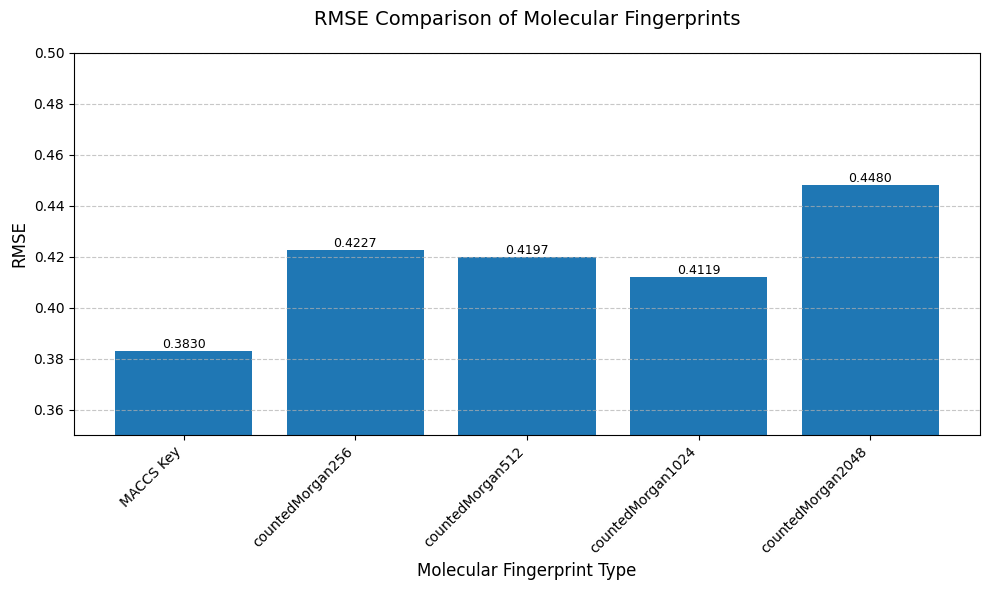

In [30]:
# 数据准备
fingerprints = ['MACCS Key', 'countedMorgan256', 'countedMorgan512', 'countedMorgan1024', 'countedMorgan2048']
rmse_values = [0.3830, 0.4227, 0.4197, 0.4119, 0.4480]

# 创建柱状图
plt.figure(figsize=(10, 6))
bars = plt.bar(fingerprints, rmse_values, color='#1f77b4')

# 添加标题和标签
plt.title('RMSE Comparison of Molecular Fingerprints', fontsize=14, pad=20)
plt.xlabel('Molecular Fingerprint Type', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylim(0.35, 0.50)  # 优化y轴范围

# 在柱子上方显示数值
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom',
             fontsize=9)

# 添加网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 调整布局防止文字被截断
plt.tight_layout()

# 显示图表
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler

cMorgan_DF_512_1 = pd.read_excel('processed_fingerprints_512_1.xlsx', sheet_name='Sheet1', header=0)
X = cMorgan_DF_512_1.filter(regex='FP_\d+')  
y = cMorgan_DF_512_1['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

X_train.head()

,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,FP_502,FP_503,FP_504,FP_505,FP_506,FP_507,FP_508,FP_509,FP_510,FP_511
0,-0.222928,-0.438455,0.0,-0.071982,-0.175382,-0.08053,-0.069864,-0.071982,-0.123034,-0.076373,...,-0.141397,-0.050833,-0.088273,-0.225612,-0.102062,-0.254432,-0.102062,0.0,-0.110182,-0.188258
1,-0.222928,-0.438455,0.0,-0.071982,-0.175382,-0.08053,-0.069864,-0.071982,-0.123034,-0.076373,...,-0.141397,-0.050833,-0.088273,-0.225612,-0.102062,-0.254432,-0.102062,0.0,-0.110182,-0.188258
2,-0.222928,1.151456,0.0,-0.071982,-0.175382,-0.08053,-0.069864,-0.071982,-0.123034,-0.076373,...,-0.141397,-0.050833,-0.088273,-0.225612,-0.102062,-0.254432,-0.102062,0.0,-0.110182,-0.188258
3,-0.222928,-0.438455,0.0,-0.071982,-0.175382,-0.08053,-0.069864,-0.071982,-0.123034,-0.076373,...,-0.141397,-0.050833,-0.088273,-0.225612,-0.102062,-0.254432,-0.102062,0.0,-0.110182,-0.188258
4,-0.222928,-0.438455,0.0,-0.071982,-0.175382,-0.08053,-0.069864,-0.071982,-0.123034,-0.076373,...,-0.141397,-0.050833,-0.088273,2.644469,-0.102062,-0.254432,-0.102062,0.0,-0.110182,-0.188258


In [4]:
csMorgan_reg_512_1 = TabPFNRegressor(random_state=42,ignore_pretraining_limits=True)
csMorgan_reg_512_1.fit(X_train, y_train)
y_pred = csMorgan_reg_512_1.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\tabpfn\regressor.py:426: UserWarning: Number of features 512 is greater than the maximum Number of features 500 supported by the model. You may see degraded performance.
  X, y, feature_names_in, n_features_in = validate_Xy_fit(
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 15, 19, 25, 31, 33, 54, 59, 61, 62, 70, 77, 79, 83, 85, 89, 90, 91, 95, 96, 99, 101, 102, 103, 110, 112, 128, 129, 133, 140, 141, 142, 170, 171, 174, 176, 197, 211, 214, 216, 218, 220, 226, 228, 231, 233, 254, 262, 266, 275, 277, 283, 293, 310, 313, 318, 324, 325, 329] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 15, 19, 25, 31, 33, 54, 59, 61, 62, 70, 77, 79, 83, 85, 89, 9

TabPFN RMSE: 0.3978


In [5]:
cMorgan_DF_512_0 = pd.read_excel('processed_fingerprints_512_0.xlsx', sheet_name='Sheet1', header=0)
X = cMorgan_DF_512_0.filter(regex='FP_\d+')  
y = cMorgan_DF_512_0['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

X_train.head()

,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,FP_502,FP_503,FP_504,FP_505,FP_506,FP_507,FP_508,FP_509,FP_510,FP_511
0,0.0,-0.436425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.251882,0.0,0.0,0.0,0.0
1,0.0,-0.436425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.251882,0.0,0.0,0.0,0.0
2,0.0,1.161054,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.251882,0.0,0.0,0.0,0.0
3,0.0,-0.436425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.251882,0.0,0.0,0.0,0.0
4,0.0,-0.436425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.251882,0.0,0.0,0.0,0.0


In [6]:
csMorgan_reg_512_0 = TabPFNRegressor(random_state=42,ignore_pretraining_limits=True)
csMorgan_reg_512_0.fit(X_train, y_train)
y_pred = csMorgan_reg_512_0.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\tabpfn\regressor.py:426: UserWarning: Number of features 512 is greater than the maximum Number of features 500 supported by the model. You may see degraded performance.
  X, y, feature_names_in, n_features_in = validate_Xy_fit(
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.wa

TabPFN RMSE: 0.3967


C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [7]:
cMorgan_DF_1024_1 = pd.read_excel('processed_fingerprints_1024_1.xlsx', sheet_name='Sheet1', header=0)
X = cMorgan_DF_1024_1.filter(regex='FP_\d+')  
y = cMorgan_DF_1024_1['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

X_train.head()

,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,FP_1014,FP_1015,FP_1016,FP_1017,FP_1018,FP_1019,FP_1020,FP_1021,FP_1022,FP_1023
0,-0.06827,-0.438455,0.0,-0.071982,-0.173006,-0.08053,0.0,-0.035921,0.0,-0.062298,...,-0.084057,-0.050833,0.0,-0.225341,0.0,-0.252541,0.0,0.0,-0.110182,0.0
1,-0.06827,-0.438455,0.0,-0.071982,-0.173006,-0.08053,0.0,-0.035921,0.0,-0.062298,...,-0.084057,-0.050833,0.0,-0.225341,0.0,-0.252541,0.0,0.0,-0.110182,0.0
2,-0.06827,1.151456,0.0,-0.071982,-0.173006,-0.08053,0.0,-0.035921,0.0,-0.062298,...,-0.084057,-0.050833,0.0,-0.225341,0.0,-0.252541,0.0,0.0,-0.110182,0.0
3,-0.06827,-0.438455,0.0,-0.071982,-0.173006,-0.08053,0.0,-0.035921,0.0,-0.062298,...,-0.084057,-0.050833,0.0,-0.225341,0.0,-0.252541,0.0,0.0,-0.110182,0.0
4,-0.06827,-0.438455,0.0,-0.071982,-0.173006,-0.08053,0.0,-0.035921,0.0,-0.062298,...,-0.084057,-0.050833,0.0,2.689070,0.0,-0.252541,0.0,0.0,-0.110182,0.0


In [8]:
csMorgan_reg_1024_1 = TabPFNRegressor(random_state=42,ignore_pretraining_limits=True)
csMorgan_reg_1024_1.fit(X_train, y_train)
y_pred = csMorgan_reg_1024_1.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\tabpfn\regressor.py:426: UserWarning: Number of features 1024 is greater than the maximum Number of features 500 supported by the model. You may see degraded performance.
  X, y, feature_names_in, n_features_in = validate_Xy_fit(
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [23, 25, 27, 37, 43, 53, 60, 61, 63, 67, 71, 72, 77, 78, 79, 83, 85, 88, 90, 99, 100, 111, 136, 137, 157, 175, 177, 179, 187, 191, 212, 219, 221, 240, 248, 260, 263, 272, 301, 334, 335, 357, 361, 363, 364, 390, 392, 397, 398, 410, 420, 422, 428, 444, 455, 467, 472, 481, 493, 505, 511, 522, 538, 539, 543] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [23, 25, 27, 37, 43, 53, 60, 61,

TabPFN RMSE: 0.4094


In [9]:
cMorgan_DF_1024_0 = pd.read_excel('processed_fingerprints_1024_0.xlsx', sheet_name='Sheet1', header=0)
X = cMorgan_DF_1024_0.filter(regex='FP_\d+')  
y = cMorgan_DF_1024_0['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

X_train.head()

,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,FP_1014,FP_1015,FP_1016,FP_1017,FP_1018,FP_1019,FP_1020,FP_1021,FP_1022,FP_1023
0,0.0,-0.436425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.251882,0.0,0.0,0.0,0.0
1,0.0,-0.436425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.251882,0.0,0.0,0.0,0.0
2,0.0,1.161054,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.251882,0.0,0.0,0.0,0.0
3,0.0,-0.436425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.251882,0.0,0.0,0.0,0.0
4,0.0,-0.436425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.251882,0.0,0.0,0.0,0.0


In [10]:
csMorgan_reg_1024_0 = TabPFNRegressor(random_state=42,ignore_pretraining_limits=True)
csMorgan_reg_1024_0.fit(X_train, y_train)
y_pred = csMorgan_reg_1024_0.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\tabpfn\regressor.py:426: UserWarning: Number of features 1024 is greater than the maximum Number of features 500 supported by the model. You may see degraded performance.
  X, y, feature_names_in, n_features_in = validate_Xy_fit(
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.w

TabPFN RMSE: 0.3899


C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [61]:
#使用MACCS Key进行样本数量减少实验
#使用全数据，0.2的分割比
maccs_df = pd.read_excel('smiles_logkoh_maccs.xlsx', sheet_name='Sheet1', header=0)
X = maccs_df.filter(regex='MACCS_\d+')  
y = maccs_df['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
#训练模型
reg_1160 = TabPFNRegressor(random_state=42)
reg_1160.fit(X_train, y_train)
y_pred = reg_1160.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

TabPFN RMSE: 0.3832


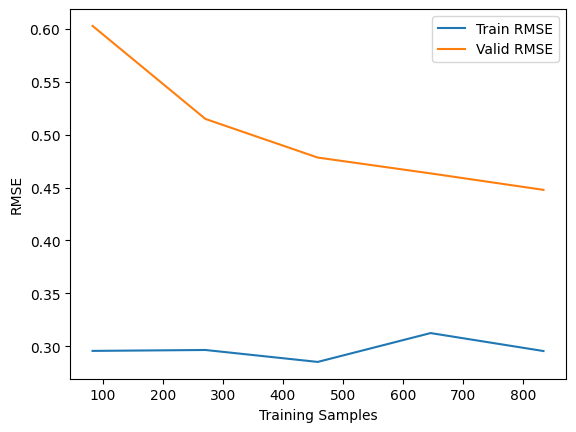

In [64]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, valid_scores = learning_curve(
    TabPFNRegressor(random_state=42), X_train, y_train, cv=10, scoring='neg_root_mean_squared_error'
)
plt.plot(train_sizes, -np.mean(train_scores, axis=1), label='Train RMSE')
plt.plot(train_sizes, -np.mean(valid_scores, axis=1), label='Valid RMSE')
plt.xlabel("Training Samples")
plt.ylabel("RMSE")
plt.legend()

In [58]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer

# 定义RMSE评估指标
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)

# 使用5折交叉验证
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(reg_1160, X_train, y_train, cv=kf, scoring=rmse_scorer)
avg_rmse = -scores.mean()  # 注意scorer的符号
print(f"5折交叉验证平均RMSE: {avg_rmse:.4f}")

5折交叉验证平均RMSE: 0.4482


In [41]:
maccs_df = pd.read_excel('smiles_logkoh_maccs.xlsx', sheet_name='Sheet1', header=0)

# 随机抽取1000行（可设置随机种子保证复现性）
maccs_df = maccs_df.sample(n=1000, random_state=42).reset_index(drop=True)
X = maccs_df.filter(regex='MACCS_\d+')
y = maccs_df['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X)

1000

In [42]:
reg_1000 = TabPFNRegressor(random_state=42)
reg_1000.fit(X_train, y_train)
y_pred = reg_1000.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

TabPFN RMSE: 0.3731


In [18]:
maccs_df = pd.read_excel('smiles_logkoh_maccs.xlsx', sheet_name='Sheet1', header=0)

# 随机抽取900行（可设置随机种子保证复现性）
maccs_df = maccs_df.sample(n=900, random_state=42).reset_index(drop=True)
X = maccs_df.filter(regex='MACCS_\d+')
y = maccs_df['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X)

900

In [19]:
reg_900 = TabPFNRegressor(random_state=42)
reg_900.fit(X_train, y_train)
y_pred = reg_900.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

TabPFN RMSE: 0.4106


In [20]:
maccs_df = pd.read_excel('smiles_logkoh_maccs.xlsx', sheet_name='Sheet1', header=0)

# 随机抽取800行（可设置随机种子保证复现性）
maccs_df = maccs_df.sample(n=800, random_state=42).reset_index(drop=True)
X = maccs_df.filter(regex='MACCS_\d+')
y = maccs_df['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X)

800

In [21]:
reg_800 = TabPFNRegressor(random_state=42)
reg_800.fit(X_train, y_train)
y_pred = reg_800.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

TabPFN RMSE: 0.4036


In [49]:
maccs_df = pd.read_excel('smiles_logkoh_maccs.xlsx', sheet_name='Sheet1', header=0)

# 随机抽取700行（可设置随机种子保证复现性）
maccs_df = maccs_df.sample(n=700, random_state=18).reset_index(drop=True)
X = maccs_df.filter(regex='MACCS_\d+')
y = maccs_df['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X)

700

In [50]:
reg_700 = TabPFNRegressor(random_state=42)
reg_700.fit(X_train, y_train)
y_pred = reg_700.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

TabPFN RMSE: 0.3633


In [51]:
y_train_pred = reg_700.predict(X_train)
train_rmse = root_mean_squared_error(y_train, y_train_pred)
print(f"Train RMSE: {train_rmse:.4f}, Test RMSE: {score:.4f}")

Train RMSE: 0.3187, Test RMSE: 0.3633


In [24]:
maccs_df = pd.read_excel('smiles_logkoh_maccs.xlsx', sheet_name='Sheet1', header=0)

# 随机抽取600行（可设置随机种子保证复现性）
maccs_df = maccs_df.sample(n=600, random_state=42).reset_index(drop=True)
X = maccs_df.filter(regex='MACCS_\d+')
y = maccs_df['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X)

600

In [25]:
reg_600 = TabPFNRegressor(random_state=42)
reg_600.fit(X_train, y_train)
y_pred = reg_600.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

TabPFN RMSE: 0.4443


In [28]:
maccs_df = pd.read_excel('smiles_logkoh_maccs.xlsx', sheet_name='Sheet1', header=0)

# 随机抽取1100行（可设置随机种子保证复现性）
maccs_df = maccs_df.sample(n=1100, random_state=42).reset_index(drop=True)
X = maccs_df.filter(regex='MACCS_\d+')
y = maccs_df['logkOH•']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X)

1100

In [29]:
reg_600 = TabPFNRegressor(random_state=42)
reg_600.fit(X_train, y_train)
y_pred = reg_600.predict(X_test)

# 评估效果
score = root_mean_squared_error(y_test, y_pred)
print(f"TabPFN RMSE: {score:.4f}")

TabPFN RMSE: 0.4101


2025-03-13 19:29:37 INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-03-13 19:29:37 INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


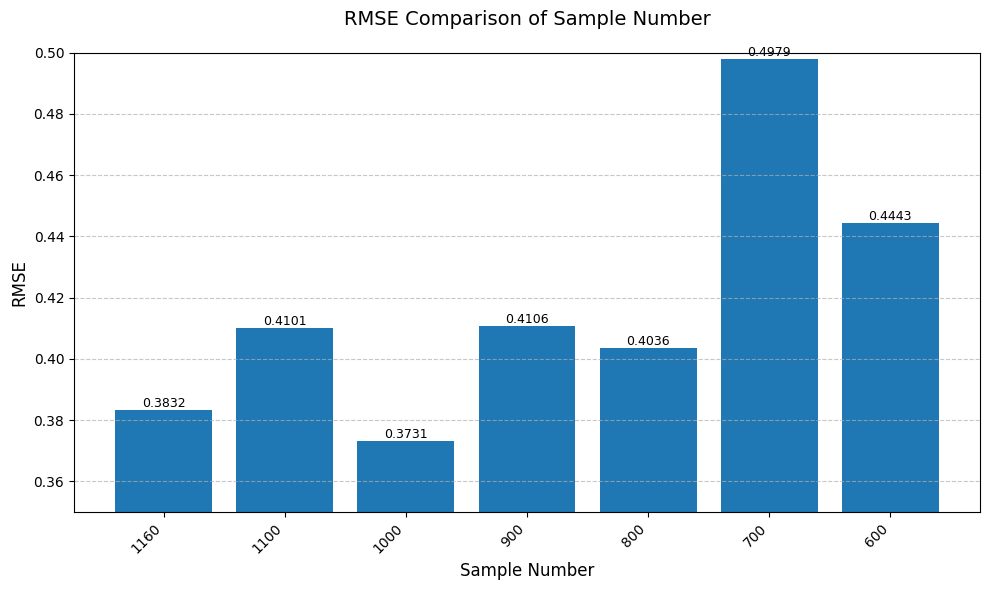

In [34]:
# 数据准备
fingerprints = ['1160', '1100', '1000', '900', '800', '700', '600']
rmse_values = [0.3832,0.4101,0.3731,0.4106,0.4036,0.4979,0.4443]

# 创建柱状图
plt.figure(figsize=(10, 6))
bars = plt.bar(fingerprints, rmse_values, color='#1f77b4')

# 添加标题和标签
plt.title('RMSE Comparison of Sample Number', fontsize=14, pad=20)
plt.xlabel('Sample Number', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylim(0.35, 0.50)  # 优化y轴范围

# 在柱子上方显示数值
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom',
             fontsize=9)

# 添加网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 调整布局防止文字被截断
plt.tight_layout()

# 显示图表
plt.show()

In [66]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tabpfn import TabPFNRegressor

# 数据加载
maccs_df = pd.read_excel('smiles_logkoh_maccs.xlsx', sheet_name='Sheet1', header=0)
X = maccs_df.filter(regex='MACCS_\d+')  
y = maccs_df['logkOH•']

# 高级评估配置
N_REPEATS = 10  # 重复次数，建议5-10
TEST_SIZE = 0.2
METRIC = 'RMSE'

def robust_evaluation(X, y, model, n_repeats=5, test_size=0.2):
    """
    执行重复随机划分的鲁棒性评估，返回：
    - 各次实验的评估指标
    - 统计量（均值±标准差）
    """
    scores = []
    
    for i in range(n_repeats):
        # 动态随机种子确保可复现性
        random_seed = 42 + i  
        
        # 数据划分（回归任务无需分层）
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, 
            test_size=test_size,
            random_state=random_seed
        )
        
        # 模型训练与预测
        current_model = model.__class__(**model.get_params())  # 创建新实例
        current_model.fit(X_train, y_train)
        y_pred = current_model.predict(X_test)
        
        # 计算指标
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        scores.append(rmse)
    
    # 统计汇总
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    
    return scores, (mean_score, std_score)

# 初始化模型（保持你的原始配置）
reg_1160 = TabPFNRegressor(random_state=42)

# 执行鲁棒性评估
rmse_results, (mean_rmse, std_rmse) = robust_evaluation(X, y, reg_1160, N_REPEATS, TEST_SIZE)

# 结果可视化输出
print(f"\n评估配置：{N_REPEATS}次重复随机划分 (test_size={TEST_SIZE})")
print("----------------------------------------")
print(f"每次 RMSE 结果：\n{[f'{x:.4f}' for x in rmse_results]}")
print("----------------------------------------")
print(f"平均 {METRIC}: {mean_rmse:.4f} ± {std_rmse:.4f} (1 SD)")
print(f"波动范围: [{np.min(rmse_results):.4f}, {np.max(rmse_results):.4f}]")
print("----------------------------------------")

# 可选：与单次划分对比
single_rmse = rmse_results[0]  # 初始种子42的结果
print(f"单次划分 vs 重复验证：")
print(f"单次 RMSE: {single_rmse:.4f} | 平均 RMSE: {mean_rmse:.4f} (±{std_rmse:.4f})")
if abs(single_rmse - mean_rmse) > std_rmse:
    print("\n[注意] 单次评估与平均值的差异超过1个标准差，建议增加重复次数至10次")


评估配置：10次重复随机划分 (test_size=0.2)
----------------------------------------
每次 RMSE 结果：
['0.3832', '0.4246', '0.3929', '0.4372', '0.3876', '0.3552', '0.4446', '0.4250', '0.4318', '0.4523']
----------------------------------------
平均 RMSE: 0.4135 ± 0.0301 (1 SD)
波动范围: [0.3552, 0.4523]
----------------------------------------
单次划分 vs 重复验证：
单次 RMSE: 0.3832 | 平均 RMSE: 0.4135 (±0.0301)

[注意] 单次评估与平均值的差异超过1个标准差，建议增加重复次数至10次


Data Fraction: 0.1 | Samples: 92 | RMSE: 0.5742
Data Fraction: 0.1 | Samples: 101 | RMSE: 0.5633
Data Fraction: 0.1 | Samples: 109 | RMSE: 0.5517
Data Fraction: 0.1 | Samples: 117 | RMSE: 0.5526
Data Fraction: 0.1 | Samples: 126 | RMSE: 0.5512
Data Fraction: 0.1 | Samples: 134 | RMSE: 0.5473
Data Fraction: 0.2 | Samples: 143 | RMSE: 0.5387
Data Fraction: 0.2 | Samples: 151 | RMSE: 0.5349
Data Fraction: 0.2 | Samples: 160 | RMSE: 0.5183
Data Fraction: 0.2 | Samples: 168 | RMSE: 0.5196
Data Fraction: 0.2 | Samples: 176 | RMSE: 0.5233
Data Fraction: 0.2 | Samples: 185 | RMSE: 0.5277
Data Fraction: 0.2 | Samples: 193 | RMSE: 0.5274
Data Fraction: 0.2 | Samples: 202 | RMSE: 0.5201
Data Fraction: 0.2 | Samples: 210 | RMSE: 0.5066
Data Fraction: 0.2 | Samples: 219 | RMSE: 0.5072
Data Fraction: 0.2 | Samples: 227 | RMSE: 0.5157
Data Fraction: 0.3 | Samples: 235 | RMSE: 0.5119
Data Fraction: 0.3 | Samples: 244 | RMSE: 0.5059
Data Fraction: 0.3 | Samples: 252 | RMSE: 0.5062
Data Fraction: 0.3 | 

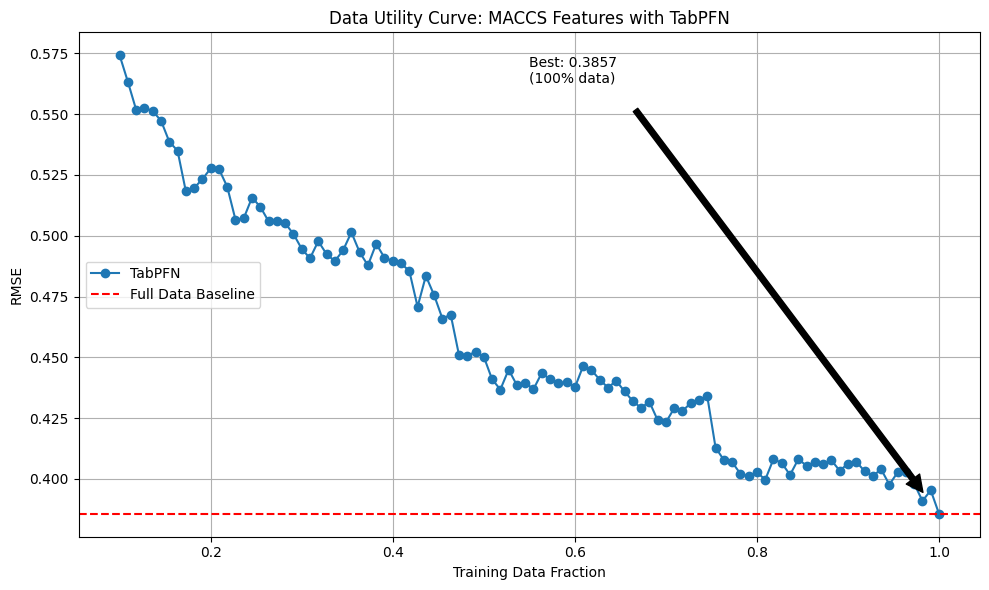

In [10]:
#通过数据效用曲线来评估数据量的影响
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNRegressor
import pandas as pd

# 读取数据
maccs_df = pd.read_excel('smiles_logkoh_maccs.xlsx', sheet_name='Sheet1', header=0)
X = maccs_df.filter(regex='MACCS_\d+')  
y = maccs_df['logkOH•']

# 固定测试集（全量数据的20%）
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True  # 重要！确保训练集顺序可复现
)

# 定义数据比例范围（总训练数据的10%-100%）
fractions = np.linspace(0.1, 1.0, 100)
rmse_scores = []

# 预训练模型初始化（避免重复加载）
reg = TabPFNRegressor(device='cuda')  # 根据硬件选择cpu/cuda

# 构建效用曲线
for frac in fractions:
    # 计算实际样本数
    n_samples = int(len(X_train_full) * frac)
    
    # 提取递增数据集（利用预打乱特性）
    X_train = X_train_full.iloc[:n_samples]
    y_train = y_train_full.iloc[:n_samples]
    
    # 模型训练与推理
    reg.fit(X_train.values, y_train.values)  # 转换为numpy加速
    y_pred = reg.predict(X_test.values)
    
    # 评估指标
    rmse = np.sqrt(np.mean((y_test.values - y_pred)**2))
    rmse_scores.append(rmse)
    print(f"Data Fraction: {frac:.1f} | Samples: {n_samples} | RMSE: {rmse:.4f}")

# 可视化曲线
plt.figure(figsize=(10, 6))
plt.plot(fractions, rmse_scores, 'o-', label='TabPFN')
plt.axhline(y=rmse_scores[-1], color='r', linestyle='--', label='Full Data Baseline')

# 标注关键拐点
min_idx = np.argmin(rmse_scores)
plt.annotate(f'Best: {rmse_scores[min_idx]:.4f}\n({fractions[min_idx]:.0%} data)',
             xy=(fractions[min_idx], rmse_scores[min_idx]),
             xytext=(0.5, 0.9), textcoords='axes fraction',
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Data Utility Curve: MACCS Features with TabPFN')
plt.xlabel('Training Data Fraction')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

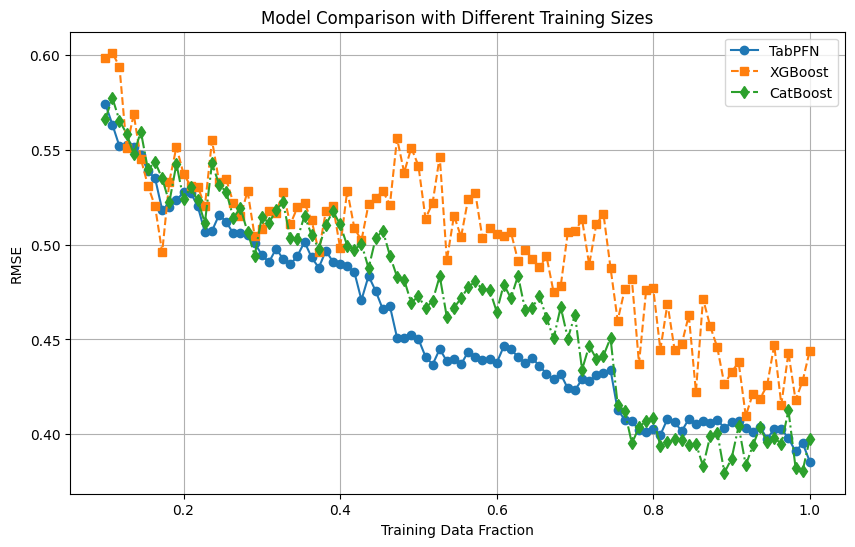

In [11]:
xgb_scores = []
catboost_scores = []  # 新增CatBoost评分列表

for frac in fractions:
    n_samples = int(len(X_train_full) * frac)
    X_train = X_train_full.iloc[:n_samples]
    y_train = y_train_full.iloc[:n_samples]
    
    # 原有XGBoost模型
    xgb_model = XGBRegressor(n_estimators=100)
    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_test)
    xgb_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    
    # 新增CatBoost模型
    cat_model = CatBoostRegressor(iterations=100, verbose=0)  # verbose=0关闭训练日志
    cat_model.fit(X_train, y_train)
    y_pred_cat = cat_model.predict(X_test)
    catboost_scores.append(np.sqrt(mean_squared_error(y_test, y_pred_cat)))

# 可视化对比
plt.figure(figsize=(10, 6))
plt.plot(fractions, rmse_scores, 'o-', label='TabPFN')
plt.plot(fractions, xgb_scores, 's--', label='XGBoost')
plt.plot(fractions, catboost_scores, 'd-.', label='CatBoost')  # 新增CatBoost曲线
plt.xlabel('Training Data Fraction')
plt.ylabel('RMSE')
plt.title('Model Comparison with Different Training Sizes')
plt.legend()
plt.grid(True)
plt.show()

Data Fraction: 0.1 | Samples: 92 | RMSE: 0.6325
Data Fraction: 0.1 | Samples: 101 | RMSE: 0.5981
Data Fraction: 0.1 | Samples: 109 | RMSE: 0.6163
Data Fraction: 0.1 | Samples: 117 | RMSE: 0.6150
Data Fraction: 0.1 | Samples: 126 | RMSE: 0.5873
Data Fraction: 0.1 | Samples: 134 | RMSE: 0.5622
Data Fraction: 0.2 | Samples: 143 | RMSE: 0.5444
Data Fraction: 0.2 | Samples: 151 | RMSE: 0.5452
Data Fraction: 0.2 | Samples: 160 | RMSE: 0.5417
Data Fraction: 0.2 | Samples: 168 | RMSE: 0.5297
Data Fraction: 0.2 | Samples: 176 | RMSE: 0.5086
Data Fraction: 0.2 | Samples: 185 | RMSE: 0.4932
Data Fraction: 0.2 | Samples: 193 | RMSE: 0.4968
Data Fraction: 0.2 | Samples: 202 | RMSE: 0.4845
Data Fraction: 0.2 | Samples: 210 | RMSE: 0.4956
Data Fraction: 0.2 | Samples: 219 | RMSE: 0.4854
Data Fraction: 0.2 | Samples: 227 | RMSE: 0.4944
Data Fraction: 0.3 | Samples: 235 | RMSE: 0.4958
Data Fraction: 0.3 | Samples: 244 | RMSE: 0.4957
Data Fraction: 0.3 | Samples: 252 | RMSE: 0.4856
Data Fraction: 0.3 | 

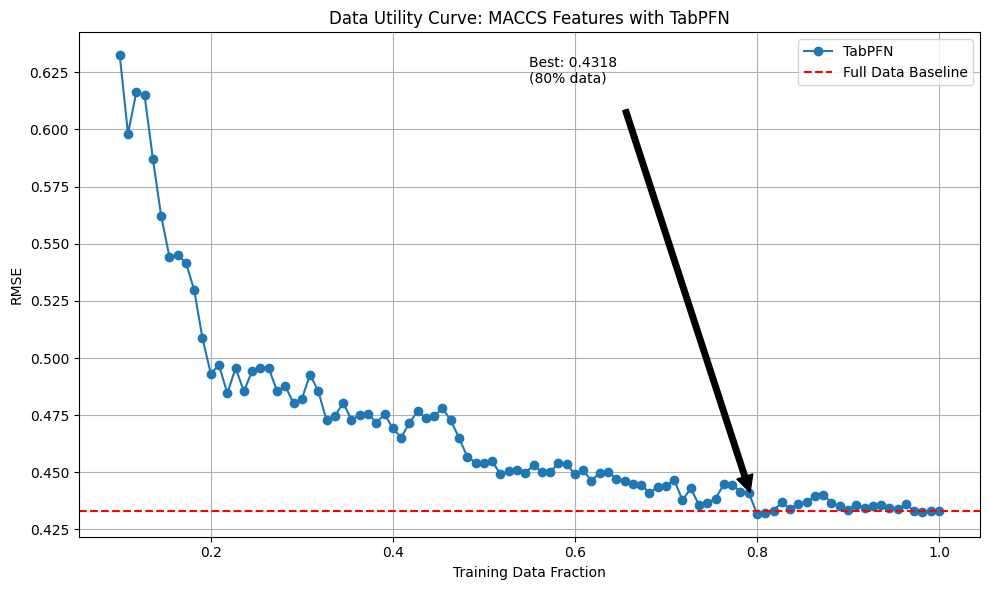

In [12]:
# 改变随机种子（探讨随机变量的影响）
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=50,
    shuffle=True  # 重要！确保训练集顺序可复现
)

# 定义数据比例范围（总训练数据的10%-100%）
fractions = np.linspace(0.1, 1.0, 100)
rmse_scores = []

# 预训练模型初始化（避免重复加载）
reg = TabPFNRegressor(device='cuda')  # 根据硬件选择cpu/cuda

# 构建效用曲线
for frac in fractions:
    # 计算实际样本数
    n_samples = int(len(X_train_full) * frac)
    
    # 提取递增数据集（利用预打乱特性）
    X_train = X_train_full.iloc[:n_samples]
    y_train = y_train_full.iloc[:n_samples]
    
    # 模型训练与推理
    reg.fit(X_train.values, y_train.values)  # 转换为numpy加速
    y_pred = reg.predict(X_test.values)
    
    # 评估指标
    rmse = np.sqrt(np.mean((y_test.values - y_pred)**2))
    rmse_scores.append(rmse)
    print(f"Data Fraction: {frac:.1f} | Samples: {n_samples} | RMSE: {rmse:.4f}")

# 可视化曲线
plt.figure(figsize=(10, 6))
plt.plot(fractions, rmse_scores, 'o-', label='TabPFN')
plt.axhline(y=rmse_scores[-1], color='r', linestyle='--', label='Full Data Baseline')

# 标注关键拐点
min_idx = np.argmin(rmse_scores)
plt.annotate(f'Best: {rmse_scores[min_idx]:.4f}\n({fractions[min_idx]:.0%} data)',
             xy=(fractions[min_idx], rmse_scores[min_idx]),
             xytext=(0.5, 0.9), textcoords='axes fraction',
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Data Utility Curve: MACCS Features with TabPFN')
plt.xlabel('Training Data Fraction')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Data Fraction: 0.1 | Samples: 92 | RMSE: 0.5382
Data Fraction: 0.1 | Samples: 101 | RMSE: 0.5430
Data Fraction: 0.1 | Samples: 109 | RMSE: 0.5469
Data Fraction: 0.1 | Samples: 117 | RMSE: 0.5683
Data Fraction: 0.1 | Samples: 126 | RMSE: 0.5551
Data Fraction: 0.1 | Samples: 134 | RMSE: 0.5545
Data Fraction: 0.2 | Samples: 143 | RMSE: 0.5390
Data Fraction: 0.2 | Samples: 151 | RMSE: 0.5457
Data Fraction: 0.2 | Samples: 160 | RMSE: 0.5159
Data Fraction: 0.2 | Samples: 168 | RMSE: 0.5198
Data Fraction: 0.2 | Samples: 176 | RMSE: 0.5096
Data Fraction: 0.2 | Samples: 185 | RMSE: 0.5143
Data Fraction: 0.2 | Samples: 193 | RMSE: 0.4853
Data Fraction: 0.2 | Samples: 202 | RMSE: 0.4941
Data Fraction: 0.2 | Samples: 210 | RMSE: 0.4929
Data Fraction: 0.2 | Samples: 219 | RMSE: 0.4965
Data Fraction: 0.2 | Samples: 227 | RMSE: 0.4956
Data Fraction: 0.3 | Samples: 235 | RMSE: 0.4969
Data Fraction: 0.3 | Samples: 244 | RMSE: 0.4776
Data Fraction: 0.3 | Samples: 252 | RMSE: 0.4701
Data Fraction: 0.3 | 

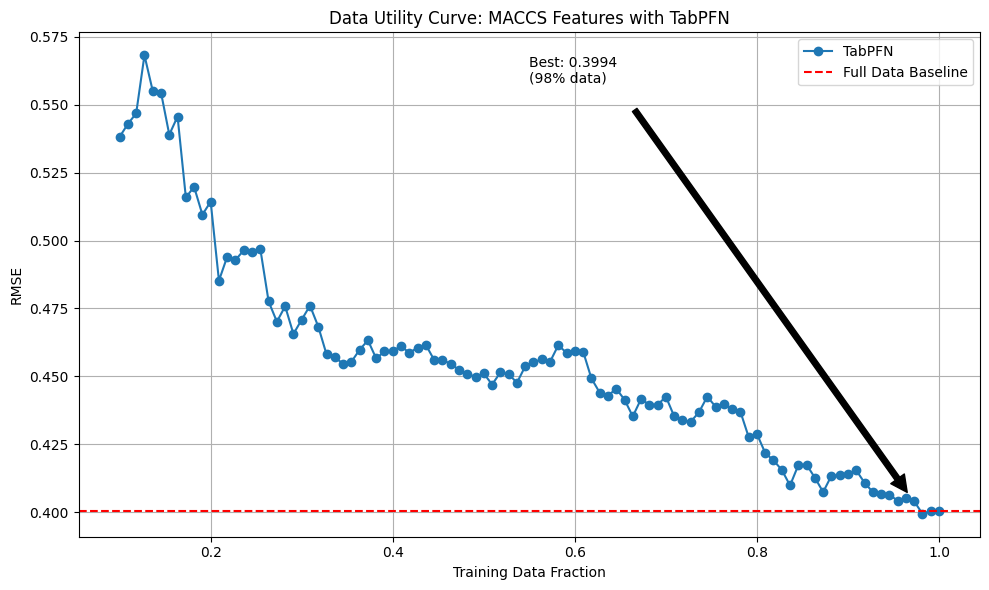

In [16]:
# 改变随机种子（探讨随机变量的影响）
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=101,
    shuffle=True  # 重要！确保训练集顺序可复现
)

# 定义数据比例范围（总训练数据的10%-100%）
fractions = np.linspace(0.1, 1.0, 100)
rmse_scores = []

# 预训练模型初始化（避免重复加载）
reg = TabPFNRegressor(device='cuda')  # 根据硬件选择cpu/cuda

# 构建效用曲线
for frac in fractions:
    # 计算实际样本数
    n_samples = int(len(X_train_full) * frac)
    
    # 提取递增数据集（利用预打乱特性）
    X_train = X_train_full.iloc[:n_samples]
    y_train = y_train_full.iloc[:n_samples]
    
    # 模型训练与推理
    reg.fit(X_train.values, y_train.values)  # 转换为numpy加速
    y_pred = reg.predict(X_test.values)
    
    # 评估指标
    rmse = np.sqrt(np.mean((y_test.values - y_pred)**2))
    rmse_scores.append(rmse)
    print(f"Data Fraction: {frac:.1f} | Samples: {n_samples} | RMSE: {rmse:.4f}")

# 可视化曲线
plt.figure(figsize=(10, 6))
plt.plot(fractions, rmse_scores, 'o-', label='TabPFN')
plt.axhline(y=rmse_scores[-1], color='r', linestyle='--', label='Full Data Baseline')

# 标注关键拐点
min_idx = np.argmin(rmse_scores)
plt.annotate(f'Best: {rmse_scores[min_idx]:.4f}\n({fractions[min_idx]:.0%} data)',
             xy=(fractions[min_idx], rmse_scores[min_idx]),
             xytext=(0.5, 0.9), textcoords='axes fraction',
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Data Utility Curve: MACCS Features with TabPFN')
plt.xlabel('Training Data Fraction')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [2]:
# 读取数据
maccs_df = pd.read_excel('categorized_maccs.xlsx', sheet_name='Sheet1', header=0)
X = maccs_df.filter(regex='MACCS_\d+')
y = maccs_df['logkOH•']
stratify_column = maccs_df['chemical class-98']

# 移除常数列
constant_cols = X.columns[X.nunique() == 1]
X = X.drop(columns=constant_cols)

In [6]:
# 分层划分数据集（测试集比例设为20%，可根据需求调整test_size和random_state）
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    stratify=stratify_column,  # 关键参数：按化学类别分层
    random_state=42
)

In [7]:
reg = TabPFNRegressor(random_state=101)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 预测训练集结果
y_train_pred = reg.predict(X_train)

# 计算评估指标
def calculate_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, r2, mae

# 训练集指标
rmse_train, r2_train, mae_train = calculate_metrics(y_train, y_train_pred)

# 测试集指标
rmse_test, r2_test, mae_test = calculate_metrics(y_test, y_pred)

# 打印评估结果
print("训练集评估指标:")
print(f"RMSE: {rmse_train:.4f}, R²: {r2_train:.4f}, MAE: {mae_train:.4f}")
print("\n测试集评估指标:")
print(f"RMSE: {rmse_test:.4f}, R²: {r2_test:.4f}, MAE: {mae_test:.4f}")

训练集评估指标:
RMSE: 0.2256, R²: 0.8742, MAE: 0.1552

测试集评估指标:
RMSE: 0.3066, R²: 0.7544, MAE: 0.2160


C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
# 创建结果DataFrame
train_results = pd.DataFrame({
    '真实值': y_train,
    '预测值': y_train_pred
}).reset_index(drop=True)

test_results = pd.DataFrame({
    '真实值': y_test.reset_index(drop=True),
    '预测值': y_pred
})

# 导出到Excel
with pd.ExcelWriter('预测结果.xlsx', engine='openpyxl') as writer:
    train_results.to_excel(writer, sheet_name='训练集', index=False)
    test_results.to_excel(writer, sheet_name='测试集', index=False)
    pd.DataFrame({
        '数据集': ['训练集', '测试集'],
        'RMSE': [rmse_train, rmse_test],
        'R²': [r2_train, r2_test],
        'MAE': [mae_train, mae_test]
    }).to_excel(writer, sheet_name='评估指标', index=False)